# 11i — Manuscript figures for Ecological Economics

Generates 12 publication-quality figures in English, without titles, ready for the manuscript.

**Style:** Elsevier-friendly. Sans-serif fonts ~9pt, no gridlines unless useful, colorblind-safe palette, no figure titles.

**Output:** all figures saved as both PDF (vector, primary) and PNG (300 dpi, preview) under `figures/manuscript/`.

**Pre-conditions in Drive:**
- All previous outputs in `data/interim/`: att_t1_main.csv, att_canais_main.csv, att_substituicao_pam.csv, event_study_consolidado.csv, att_b4m5_por_tercil.csv, att_b4m5_event_por_tercil.csv, b4m7_balanco_co2eq.csv, b4m8_intensidade_carbono.csv, b4m8_robustez_decomposicao.csv
- `data/raw/psm_baseline/` for PSM scores
- `panel_canavieiro_main.csv` for cohort distribution

**Note:** does NOT generate the map (you have it) nor the timeline figure.

## Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import sys
from pathlib import Path
BASE_DIR = Path("/content/drive/MyDrive/Renovabio - EcoEco")
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

FIG_DIR = BASE_DIR / "figures" / "manuscript"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved at: {FIG_DIR}")

Mounted at /content/drive
Figures will be saved at: /content/drive/MyDrive/Renovabio - EcoEco/figures/manuscript


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Publication style — Elsevier-compatible
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth": 1.2,
    "patch.linewidth": 0.5,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype": 42,  # embed fonts (avoid Type 3)
    "ps.fonttype": 42,
})

# Colorblind-safe palette (Wong 2011, Nature Methods)
COLORS = {
    "treated":     "#0072B2",  # blue
    "control":     "#999999",  # grey
    "positive":    "#D55E00",  # vermillion
    "negative":    "#009E73",  # bluish green
    "neutral":     "#56B4E9",  # sky blue
    "highlight":   "#E69F00",  # orange
    "purple":      "#CC79A7",  # reddish purple
    "yellow":      "#F0E442",  # yellow
}

def save_fig(fig, name, formats=("pdf", "png")):
    for fmt in formats:
        path = FIG_DIR / f"{name}.{fmt}"
        fig.savefig(path, format=fmt)
        print(f"  saved: {path.name}")

# Helper for figure sizes in mm (Elsevier columns)
def mm_to_inch(mm): return mm / 25.4
SINGLE_COL = (mm_to_inch(85), mm_to_inch(70))   # ~3.35 x 2.76 in
DOUBLE_COL = (mm_to_inch(170), mm_to_inch(120)) # ~6.69 x 4.72 in
DOUBLE_TALL = (mm_to_inch(170), mm_to_inch(160))

from pipeline.config import interim
print("setup OK")

setup OK


## F1 — PSM propensity score density (treated vs control, before/after)

In [3]:
# Reusa scores PSM do passo B3
import os
psm_path = BASE_DIR / "data" / "interim" / "psm_scores_FULL2.csv"
if not psm_path.exists():
    # Fallback: try other spec names
    candidates = list((BASE_DIR / "data" / "interim").glob("psm_scores*.csv"))
    if candidates:
        psm_path = candidates[0]
        print(f"Using PSM scores from: {psm_path.name}")
    else:
        print("WARN: no psm_scores file found. F1 will be skipped.")
        psm_path = None

if psm_path and psm_path.exists():
    psm = pd.read_csv(psm_path, dtype={"geocode": str})
    # Espera colunas: geocode, treated, pscore, matched (boolean opcional)
    if "pscore" not in psm.columns:
        pscore_cands = [c for c in psm.columns if "score" in c.lower() or "pscore" in c.lower() or "ps" in c.lower()]
        if pscore_cands:
            psm = psm.rename(columns={pscore_cands[0]: "pscore"})

    fig, axes = plt.subplots(1, 2, figsize=DOUBLE_COL, sharey=True)

    # Panel A: before matching (all 842 munis)
    for label, color in [("Control", COLORS["control"]), ("Treated", COLORS["treated"])]:
        treated_val = 1 if label == "Treated" else 0
        sub = psm[psm["treated"] == treated_val]
        if len(sub) > 0:
            axes[0].hist(sub["pscore"], bins=30, alpha=0.55, color=color,
                        label=f"{label} (n={len(sub)})", density=True, edgecolor="white",
                        linewidth=0.3)
    axes[0].set_xlabel("Propensity score")
    axes[0].set_ylabel("Density")
    axes[0].text(0.02, 0.95, "(a) Before matching", transform=axes[0].transAxes,
                 fontweight="bold", fontsize=9, va="top")
    axes[0].legend(loc="upper right", frameon=False)
    axes[0].set_xlim(0, 1)

    # Panel B: after matching (filter to matched units if column exists)
    if "matched" in psm.columns:
        psm_m = psm[psm["matched"] == True]
    elif "is_in_support" in psm.columns:
        psm_m = psm[psm["is_in_support"] == True]
    else:
        # Approximate by common support [0.1, 0.9]
        psm_m = psm[psm["pscore"].between(0.05, 0.95)]

    for label, color in [("Control", COLORS["control"]), ("Treated", COLORS["treated"])]:
        treated_val = 1 if label == "Treated" else 0
        sub = psm_m[psm_m["treated"] == treated_val]
        if len(sub) > 0:
            axes[1].hist(sub["pscore"], bins=30, alpha=0.55, color=color,
                        label=f"{label} (n={len(sub)})", density=True, edgecolor="white",
                        linewidth=0.3)
    axes[1].set_xlabel("Propensity score")
    axes[1].text(0.02, 0.95, "(b) After matching (common support)", transform=axes[1].transAxes,
                 fontweight="bold", fontsize=9, va="top")
    axes[1].legend(loc="upper right", frameon=False)
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    save_fig(fig, "F1_psm_overlap")
    plt.show()
else:
    print("F1 skipped (no psm_scores file)")

WARN: no psm_scores file found. F1 will be skipped.
F1 skipped (no psm_scores file)


## F2 — Treatment cohort distribution

Cohort distribution:
g_m
2019      2
2020    142
2021     40
2022      8
2023      2
Name: count, dtype: int64
  saved: F2_cohort_distribution.pdf
  saved: F2_cohort_distribution.png


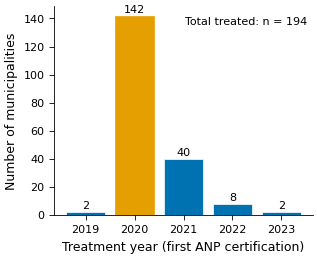

In [4]:
# Distribuição de coortes de tratamento entre os 194 canavieiros tratados
panel = pd.read_csv(interim("panel_canavieiro_main.csv"), dtype={"geocode": str})

cohort_dist = (
    panel[panel["g_m"].notna()]
    .drop_duplicates("geocode")["g_m"].astype(int)
    .value_counts().sort_index()
)
print("Cohort distribution:")
print(cohort_dist)

fig, ax = plt.subplots(figsize=SINGLE_COL)
bars = ax.bar(cohort_dist.index, cohort_dist.values,
              color=COLORS["treated"], edgecolor="white", linewidth=0.5)

# Highlight dominant cohort (2020)
max_cohort = cohort_dist.idxmax()
for bar, year in zip(bars, cohort_dist.index):
    if year == max_cohort:
        bar.set_color(COLORS["highlight"])
    ax.text(year, bar.get_height() + 1, f"{int(bar.get_height())}",
            ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Treatment year (first ANP certification)")
ax.set_ylabel("Number of municipalities")
ax.set_xticks(cohort_dist.index)
total = int(cohort_dist.sum())
ax.text(0.98, 0.95, f"Total treated: n = {total}", transform=ax.transAxes,
        ha="right", va="top", fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2))

plt.tight_layout()
save_fig(fig, "F2_cohort_distribution")
plt.show()

## F3 — Covariate balance (Love plot)

In [5]:
# Standardized mean differences before/after matching
# Need: covariate name, SMD_before, SMD_after

balance_path = interim("psm_balance_FULL2.csv")
if not balance_path.exists():
    # Try alternatives
    candidates = list((BASE_DIR / "data" / "interim").glob("*balance*.csv"))
    if candidates:
        balance_path = candidates[0]
        print(f"Using balance file: {balance_path.name}")
    else:
        print("WARN: no balance file found. F3 will be skipped.")
        balance_path = None

if balance_path and balance_path.exists():
    bal = pd.read_csv(balance_path)
    # Espera colunas: covariate, smd_before, smd_after
    # Ajustar se nomes diferem
    smd_before_col = [c for c in bal.columns if "before" in c.lower() or "raw" in c.lower()]
    smd_after_col = [c for c in bal.columns if "after" in c.lower() or "matched" in c.lower() or "weight" in c.lower()]
    cov_col = [c for c in bal.columns if "cov" in c.lower() or "var" in c.lower() or "name" in c.lower()]

    if smd_before_col and smd_after_col and cov_col:
        bal = bal.rename(columns={smd_before_col[0]: "smd_before",
                                   smd_after_col[0]: "smd_after",
                                   cov_col[0]: "covariate"})
        # Ordenar por SMD absoluto antes (pior caso no topo)
        bal["abs_before"] = bal["smd_before"].abs()
        bal = bal.sort_values("abs_before", ascending=True).reset_index(drop=True)

        # Limitar a top 25 mais desbalanceadas para legibilidade
        if len(bal) > 25:
            bal = bal.tail(25)

        fig, ax = plt.subplots(figsize=(mm_to_inch(85), mm_to_inch(140)))
        y_pos = np.arange(len(bal))
        ax.scatter(bal["smd_before"], y_pos, color=COLORS["control"],
                   s=30, label="Before matching", marker="o", edgecolor="white", linewidth=0.4)
        ax.scatter(bal["smd_after"], y_pos, color=COLORS["treated"],
                   s=30, label="After matching", marker="D", edgecolor="white", linewidth=0.4)

        # Lines connecting paired points
        for y, b, a in zip(y_pos, bal["smd_before"], bal["smd_after"]):
            ax.plot([b, a], [y, y], color="grey", lw=0.4, alpha=0.5, zorder=0)

        # Reference lines at 0.1 (acceptable balance threshold)
        ax.axvline(0, color="black", lw=0.5, zorder=0)
        ax.axvline(0.1, color="red", lw=0.5, ls=":", alpha=0.5, zorder=0)
        ax.axvline(-0.1, color="red", lw=0.5, ls=":", alpha=0.5, zorder=0)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(bal["covariate"], fontsize=7)
        ax.set_xlabel("Standardized mean difference")
        ax.legend(loc="lower right", frameon=False)
        ax.set_xlim(-1.0, 1.0)

        plt.tight_layout()
        save_fig(fig, "F3_covariate_balance")
        plt.show()
    else:
        print("F3 skipped: balance columns not found")
else:
    print("F3 skipped (no balance file)")

Using balance file: psm_balance_smd.csv
F3 skipped: balance columns not found


## F4 — Event-study (5 panels: 4 robust + res_outros)

  saved: F4_event_study_main.pdf
  saved: F4_event_study_main.png


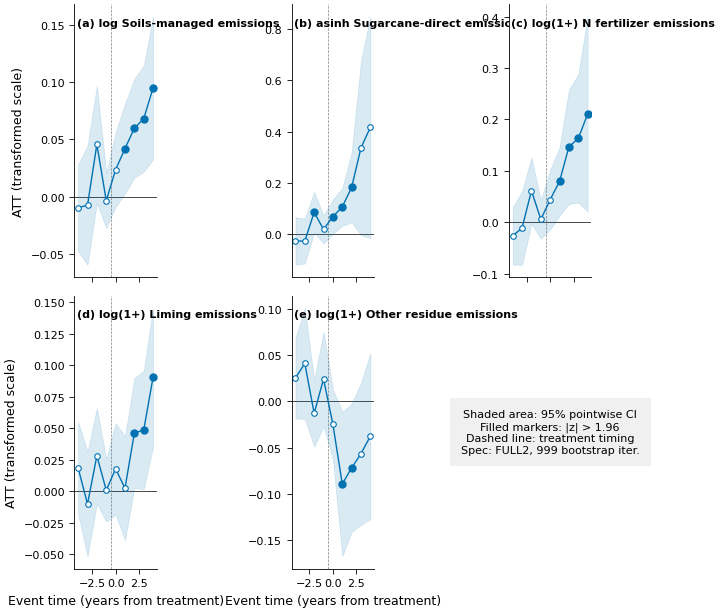

In [6]:
ev = pd.read_csv(interim("event_study_consolidado.csv"))
# Filtrar para janela t=[-4, +4] (decisão de truncar conforme v2.6)
ev = ev[(ev["event_time"] >= -4) & (ev["event_time"] <= 4)]

# 5 outcomes para mostrar
panels = [
    ("log_solos_manejados",   "log Soils-managed emissions"),
    ("asinh_cana_direto",     "asinh Sugarcane-direct emissions"),
    ("log1p_fert_n",          "log(1+) N fertilizer emissions"),
    ("log1p_calagem",         "log(1+) Liming emissions"),
    ("log1p_res_outros",      "log(1+) Other residue emissions"),
]

fig, axes = plt.subplots(2, 3, figsize=DOUBLE_TALL, sharex=True)
axes = axes.flatten()

for i, (outcome, label) in enumerate(panels):
    ax = axes[i]
    sub = ev[ev["outcome"] == outcome].sort_values("event_time")
    if sub.empty:
        ax.text(0.5, 0.5, f"No data for\n{outcome}",
                transform=ax.transAxes, ha="center", va="center")
        continue

    ts = sub["event_time"].values
    atts = sub["ATT"].values
    ses = sub["SE"].values
    ci_lo = atts - 1.96 * ses
    ci_hi = atts + 1.96 * ses

    # Pontos significantes em destaque
    is_sig = np.abs(atts / ses) > 1.96

    # CI bands
    ax.fill_between(ts, ci_lo, ci_hi, color=COLORS["treated"], alpha=0.15)
    # Linha conectora
    ax.plot(ts, atts, color=COLORS["treated"], lw=1.0, marker="o", markersize=4,
            markerfacecolor="white", markeredgecolor=COLORS["treated"], markeredgewidth=0.8)
    # Pontos significantes em cor cheia
    if is_sig.any():
        ax.plot(ts[is_sig], atts[is_sig], "o", color=COLORS["treated"],
                markersize=5, zorder=10)

    ax.axhline(0, color="black", lw=0.5, zorder=0)
    ax.axvline(-0.5, color="grey", lw=0.5, ls="--", zorder=0)  # treatment marker

    # Label do painel
    panel_letter = chr(ord("a") + i)
    ax.text(0.03, 0.95, f"({panel_letter}) {label}", transform=ax.transAxes,
            fontweight="bold", fontsize=8, va="top")

    if i >= 3:
        ax.set_xlabel("Event time (years from treatment)")
    if i % 3 == 0:
        ax.set_ylabel("ATT (transformed scale)")

# Hide unused subplot
axes[5].axis("off")
# Adicionar nota na célula vazia
axes[5].text(0.5, 0.5, "Shaded area: 95% pointwise CI\n"
                       "Filled markers: |z| > 1.96\n"
                       "Dashed line: treatment timing\n"
                       "Spec: FULL2, 999 bootstrap iter.",
             transform=axes[5].transAxes, ha="center", va="center",
             fontsize=8, bbox=dict(facecolor="#F0F0F0", edgecolor="none", pad=8))

plt.tight_layout()
save_fig(fig, "F4_event_study_main")
plt.show()

## F5 — Forest plot ATTs B4.M.4 decomposition (4 outcomes × 4 specs)

  saved: F5_att_decomposition.pdf
  saved: F5_att_decomposition.png


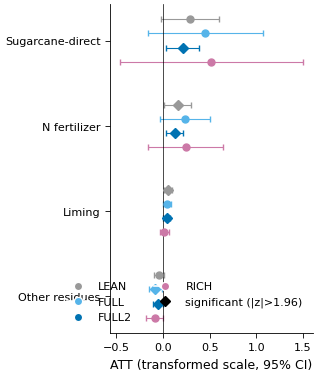

In [7]:
att = pd.read_csv(interim("att_canais_main.csv"))

outcomes_order = [
    ("asinh_cana_direto",  "Sugarcane-direct"),
    ("log1p_fert_n",       "N fertilizer"),
    ("log1p_calagem",      "Liming"),
    ("log1p_res_outros",   "Other residues"),
]
specs_order = ["LEAN", "FULL", "FULL2", "RICH"]
spec_colors = {"LEAN": COLORS["control"], "FULL": COLORS["neutral"],
               "FULL2": COLORS["treated"], "RICH": COLORS["purple"]}

fig, ax = plt.subplots(figsize=(mm_to_inch(85), mm_to_inch(100)))

y_offset = 0
yticks = []
yticklabels = []
for outc, label in outcomes_order:
    for j, spec in enumerate(specs_order):
        sub = att[(att["outcome"] == outc) & (att["spec"] == spec)]
        if sub.empty: continue
        a = float(sub.iloc[0]["ATT"])
        s = float(sub.iloc[0]["SE"])
        ci_lo, ci_hi = a - 1.96 * s, a + 1.96 * s
        is_sig = abs(a/s) > 1.96 if s > 0 else False

        y = y_offset + j * 0.2
        color = spec_colors[spec]
        ax.errorbar(a, y, xerr=[[a - ci_lo], [ci_hi - a]],
                    fmt="o" if not is_sig else "D",
                    color=color, ecolor=color, markersize=5,
                    elinewidth=0.8, capsize=2)
    yticks.append(y_offset + 0.3)
    yticklabels.append(label)
    y_offset += 1.2

ax.axvline(0, color="black", lw=0.5)
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.set_xlabel("ATT (transformed scale, 95% CI)")
# Custom legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=spec_colors[s],
                  markersize=6, label=s) for s in specs_order]
handles.append(Line2D([0],[0], marker="D", color="black", lw=0, markersize=5,
                       label="significant (|z|>1.96)"))
ax.legend(handles=handles, loc="lower right", frameon=False, ncol=2)
ax.invert_yaxis()

plt.tight_layout()
save_fig(fig, "F5_att_decomposition")
plt.show()

## F6 — Forest plot substitution PAM + MapBiomas (FULL2 only)

  saved: F6_substitution_pam_mapb.pdf
  saved: F6_substitution_pam_mapb.png


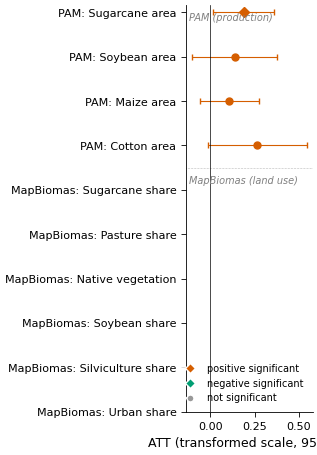

In [8]:
att_sub = pd.read_csv(interim("att_substituicao_pam.csv"))
att_sub = att_sub[att_sub["spec"] == "FULL2"]

outcomes_sub = [
    ("log1p_pam_area_cana_t",    "PAM: Sugarcane area"),
    ("asinh_pam_area_soja_t",    "PAM: Soybean area"),
    ("asinh_pam_area_milho_t",   "PAM: Maize area"),
    ("asinh_pam_area_algodao_t", "PAM: Cotton area"),
    ("log1p_share_cana_mapb",    "MapBiomas: Sugarcane share"),
    ("log1p_share_pastagem_mapb", "MapBiomas: Pasture share"),
    ("log1p_share_vegetacao_nativa_mapb", "MapBiomas: Native vegetation"),
    ("asinh_share_soja_mapb",    "MapBiomas: Soybean share"),
    ("asinh_share_silvicultura_mapb", "MapBiomas: Silviculture share"),
    ("asinh_share_urbano_infra_mapb", "MapBiomas: Urban share"),
]

fig, ax = plt.subplots(figsize=(mm_to_inch(85), mm_to_inch(120)))
y_pos = np.arange(len(outcomes_sub))[::-1]

for i, (outc, label) in enumerate(outcomes_sub):
    sub = att_sub[att_sub["outcome"] == outc]
    if sub.empty: continue
    a = float(sub.iloc[0]["ATT"])
    s = float(sub.iloc[0]["SE"])
    ci_lo, ci_hi = a - 1.96 * s, a + 1.96 * s
    is_sig = abs(a/s) > 1.96 if s > 0 else False
    color = COLORS["positive"] if a > 0 else COLORS["negative"]
    marker = "D" if is_sig else "o"
    ax.errorbar(a, y_pos[i], xerr=[[a - ci_lo], [ci_hi - a]],
                fmt=marker, color=color, ecolor=color, markersize=5,
                elinewidth=0.8, capsize=2)

# Separator between PAM and MapBiomas blocks
ax.axhline(y_pos[3] - 0.5, color="grey", lw=0.4, ls=":")
ax.text(0.02, 0.98, "PAM (production)", transform=ax.transAxes, fontsize=7, va="top",
        color="grey", style="italic")
ax.text(0.02, 0.58, "MapBiomas (land use)", transform=ax.transAxes, fontsize=7, va="top",
        color="grey", style="italic")

ax.axvline(0, color="black", lw=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([l for _, l in outcomes_sub])
ax.set_xlabel("ATT (transformed scale, 95% CI)")

# Legend
handles = [
    Line2D([0],[0], marker="D", color="w", markerfacecolor=COLORS["positive"],
           markersize=5, label="positive significant"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor=COLORS["negative"],
           markersize=5, label="negative significant"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLORS["control"],
           markersize=5, label="not significant"),
]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=7)

plt.tight_layout()
save_fig(fig, "F6_substitution_pam_mapb")
plt.show()

## F7 — Dose-response by share-cana tercile (5 outcomes)

  saved: F7_tercil_dose_response.pdf
  saved: F7_tercil_dose_response.png


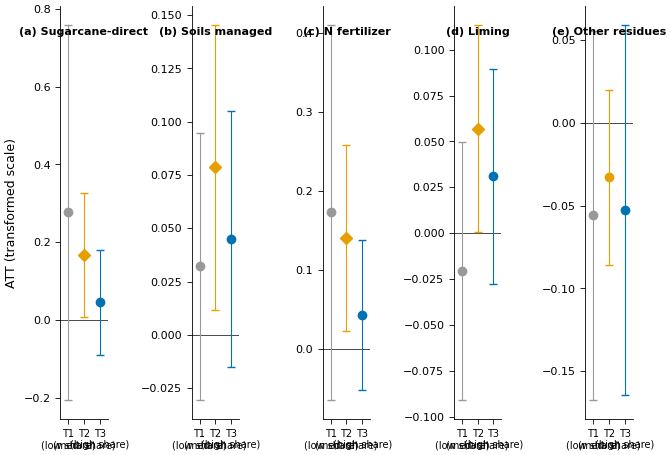

In [9]:
att_t = pd.read_csv(interim("att_b4m5_por_tercil.csv"))

outcomes_t = [
    ("asinh_cana_direto",  "Sugarcane-direct"),
    ("log_solos_manejados", "Soils managed"),
    ("log1p_fert_n",       "N fertilizer"),
    ("log1p_calagem",      "Liming"),
    ("log1p_res_outros",   "Other residues"),
]
tercis = ["T1_baixo", "T2_medio", "T3_alto"]
t_labels = ["T1\n(low share)", "T2\n(med. share)", "T3\n(high share)"]
t_colors = [COLORS["control"], COLORS["highlight"], COLORS["treated"]]

fig, axes = plt.subplots(1, 5, figsize=DOUBLE_COL, sharey=False)

for i, (outc, label) in enumerate(outcomes_t):
    ax = axes[i]
    x_pos = np.arange(len(tercis))
    for j, t in enumerate(tercis):
        sub = att_t[(att_t["outcome"] == outc) & (att_t["tercil"] == t)]
        if sub.empty: continue
        a = float(sub.iloc[0]["ATT"])
        s = float(sub.iloc[0]["SE"])
        is_sig = abs(a/s) > 1.96 if s > 0 else False
        ci_lo, ci_hi = a - 1.96 * s, a + 1.96 * s
        marker = "D" if is_sig else "o"
        ax.errorbar(j, a, yerr=[[a - ci_lo], [ci_hi - a]],
                    fmt=marker, color=t_colors[j], ecolor=t_colors[j],
                    markersize=6, elinewidth=0.8, capsize=3)
    ax.axhline(0, color="black", lw=0.5, zorder=0)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(t_labels, fontsize=7)
    ax.set_xlim(-0.5, 2.5)

    panel_letter = chr(ord("a") + i)
    ax.text(0.5, 0.95, f"({panel_letter}) {label}", transform=ax.transAxes,
            ha="center", va="top", fontweight="bold", fontsize=8)

    if i == 0:
        ax.set_ylabel("ATT (transformed scale)")

plt.tight_layout()
save_fig(fig, "F7_tercil_dose_response")
plt.show()

## F8 — Event-study sugarcane-direct by share-cana tercile

  saved: F8_event_study_tercis.pdf
  saved: F8_event_study_tercis.png


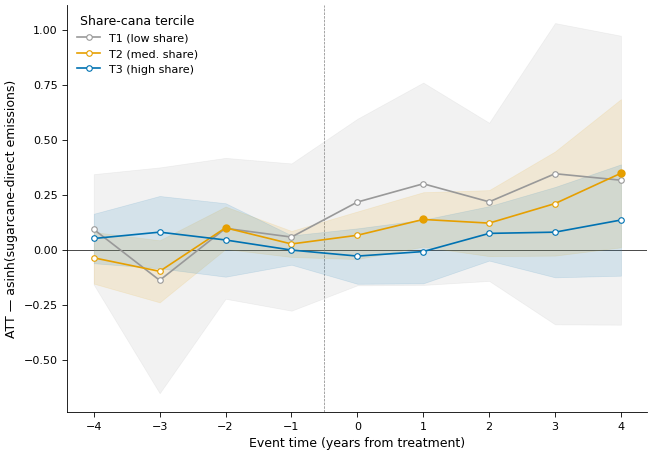

In [10]:
ev_t = pd.read_csv(interim("att_b4m5_event_por_tercil.csv"))

fig, ax = plt.subplots(figsize=DOUBLE_COL)

for j, t in enumerate(tercis):
    sub = ev_t[ev_t["tercil"] == t].sort_values("event_time")
    if sub.empty: continue
    ts = sub["event_time"].values
    atts = sub["ATT"].values
    ses = sub["SE"].values
    ci_lo = atts - 1.96 * ses
    ci_hi = atts + 1.96 * ses

    is_sig = np.abs(atts / ses) > 1.96

    ax.fill_between(ts, ci_lo, ci_hi, color=t_colors[j], alpha=0.12)
    ax.plot(ts, atts, color=t_colors[j], lw=1.2, marker="o", markersize=4,
            markerfacecolor="white", markeredgecolor=t_colors[j], markeredgewidth=0.8,
            label=t_labels[j].replace("\n"," "))
    if is_sig.any():
        ax.plot(ts[is_sig], atts[is_sig], "o", color=t_colors[j], markersize=5, zorder=10)

ax.axhline(0, color="black", lw=0.5, zorder=0)
ax.axvline(-0.5, color="grey", lw=0.5, ls="--", zorder=0)
ax.set_xlabel("Event time (years from treatment)")
ax.set_ylabel("ATT — asinh(sugarcane-direct emissions)")
ax.legend(loc="upper left", frameon=False, title="Share-cana tercile")

plt.tight_layout()
save_fig(fig, "F8_event_study_tercis")
plt.show()

## F9 — CO2eq balance per municipality, by channel

  saved: F9_co2eq_balance.pdf
  saved: F9_co2eq_balance.png


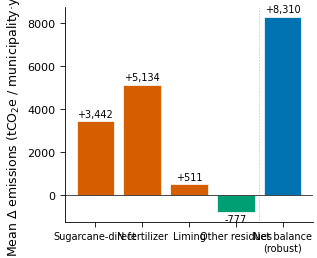

In [11]:
balanco = pd.read_csv(interim("b4m7_balanco_co2eq.csv"))

# Médias por canal (excluir queima - INCONCLUSIVO)
channels = [
    ("delta_cana_dir",    "Sugarcane-direct"),
    ("delta_fert_n",      "N fertilizer"),
    ("delta_calagem",     "Liming"),
    ("delta_res_outros",  "Other residues"),
]

means = [balanco[c].mean() for c, _ in channels]
labels = [l for _, l in channels]
colors_bar = [COLORS["positive"] if m > 0 else COLORS["negative"] for m in means]

# Adicionar total como última barra
total_robust = sum(means)
means.append(total_robust)
labels.append("Net balance\n(robust)")
colors_bar.append(COLORS["treated"])

fig, ax = plt.subplots(figsize=SINGLE_COL)
x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, means, color=colors_bar, edgecolor="white", linewidth=0.5)

# Anotar valores
for x, m in zip(x_pos, means):
    va = "bottom" if m > 0 else "top"
    offset = 100 if m > 0 else -100
    ax.text(x, m + offset, f"{m:+,.0f}", ha="center", va=va, fontsize=7)

ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("Mean Δ emissions (tCO$_2$e / municipality·year)")
# Vertical line separator before "Net balance"
ax.axvline(len(channels) - 0.5, color="grey", lw=0.4, ls=":")

plt.tight_layout()
save_fig(fig, "F9_co2eq_balance")
plt.show()

## F10 — Scatter intensity pre vs post by municipality

  saved: F10_intensity_pre_post.pdf
  saved: F10_intensity_pre_post.png


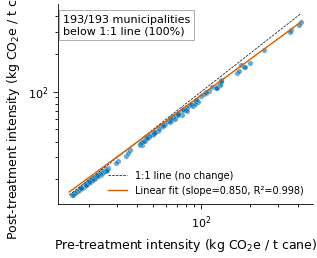

In [12]:
b4m8 = pd.read_csv(interim("b4m8_intensidade_carbono.csv"), index_col=0)

fig, ax = plt.subplots(figsize=SINGLE_COL)

ax.scatter(b4m8["intensity_pre_kgco2_ton"], b4m8["intensity_pos_kgco2_ton"],
           s=15, alpha=0.6, color=COLORS["treated"], edgecolor="white", linewidth=0.3)

# 1:1 line
max_val = max(b4m8["intensity_pre_kgco2_ton"].max(), b4m8["intensity_pos_kgco2_ton"].max())
min_val = max(0, min(b4m8["intensity_pre_kgco2_ton"].min(), b4m8["intensity_pos_kgco2_ton"].min()))
ax.plot([min_val, max_val], [min_val, max_val], color="black", lw=0.5, ls="--",
        label="1:1 line (no change)")

# Linear fit
from scipy.stats import linregress
mask = b4m8["intensity_pre_kgco2_ton"].notna() & b4m8["intensity_pos_kgco2_ton"].notna()
slope, intercept, r, _, _ = linregress(b4m8["intensity_pre_kgco2_ton"][mask],
                                        b4m8["intensity_pos_kgco2_ton"][mask])
x_line = np.array([min_val, max_val])
ax.plot(x_line, intercept + slope * x_line, color=COLORS["positive"], lw=1.0,
        label=f"Linear fit (slope={slope:.3f}, R²={r**2:.3f})")

# Annotate: % below 1:1 line
n_below = (b4m8["intensity_pos_kgco2_ton"] < b4m8["intensity_pre_kgco2_ton"]).sum()
n_total = mask.sum()
ax.text(0.02, 0.95, f"{n_below}/{n_total} municipalities\nbelow 1:1 line ({100*n_below/n_total:.0f}%)",
        transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(facecolor="white", edgecolor="grey", alpha=0.9, pad=3))

ax.set_xlabel("Pre-treatment intensity (kg CO$_2$e / t cane)")
ax.set_ylabel("Post-treatment intensity (kg CO$_2$e / t cane)")
ax.legend(loc="lower right", frameon=False, fontsize=7)
ax.set_xscale("log")
ax.set_yscale("log")

plt.tight_layout()
save_fig(fig, "F10_intensity_pre_post")
plt.show()

## F11 — Kaya decomposition by production decile

  saved: F11_kaya_by_decil.pdf
  saved: F11_kaya_by_decil.png


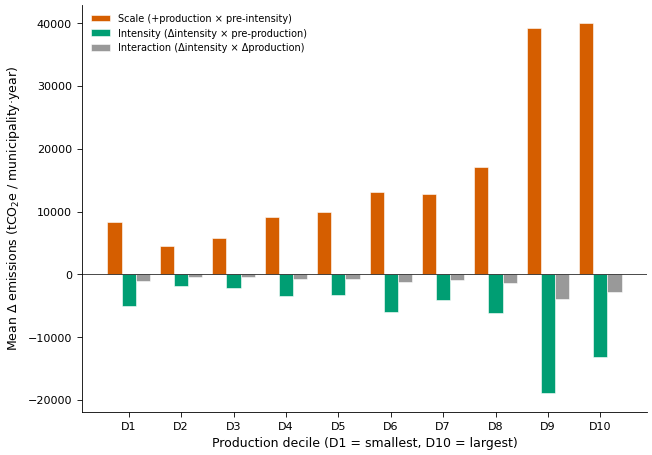

In [13]:
robustez = pd.read_csv(interim("b4m8_robustez_decomposicao.csv"), index_col=0)

# Calcular por decil
robustez["size_decil"] = robustez["size_decil"].astype(str)
por_decil = robustez.groupby("size_decil", observed=True).agg(
    termo_escala=("termo_escala_tco2e", "mean"),
    termo_int=("termo_intensidade_tco2e", "mean"),
    termo_interacao=("termo_interacao_tco2e", "mean"),
).reset_index()
# Ordenar D1 a D10
por_decil["decil_num"] = por_decil["size_decil"].str.replace("D","").astype(int)
por_decil = por_decil.sort_values("decil_num").reset_index(drop=True)

fig, ax = plt.subplots(figsize=DOUBLE_COL)

x = np.arange(len(por_decil))
width = 0.27

ax.bar(x - width, por_decil["termo_escala"], width,
       label="Scale (+production × pre-intensity)",
       color=COLORS["positive"], edgecolor="white", linewidth=0.4)
ax.bar(x, por_decil["termo_int"], width,
       label="Intensity (Δintensity × pre-production)",
       color=COLORS["negative"], edgecolor="white", linewidth=0.4)
ax.bar(x + width, por_decil["termo_interacao"], width,
       label="Interaction (Δintensity × Δproduction)",
       color=COLORS["control"], edgecolor="white", linewidth=0.4)

ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(por_decil["size_decil"], fontsize=8)
ax.set_xlabel("Production decile (D1 = smallest, D10 = largest)")
ax.set_ylabel("Mean Δ emissions (tCO$_2$e / municipality·year)")
ax.legend(loc="upper left", frameon=False, fontsize=7)

plt.tight_layout()
save_fig(fig, "F11_kaya_by_decil")
plt.show()

## F12 — Distribution of delta intensity (histogram + kernel density)

  saved: F12_intensity_distribution.pdf
  saved: F12_intensity_distribution.png


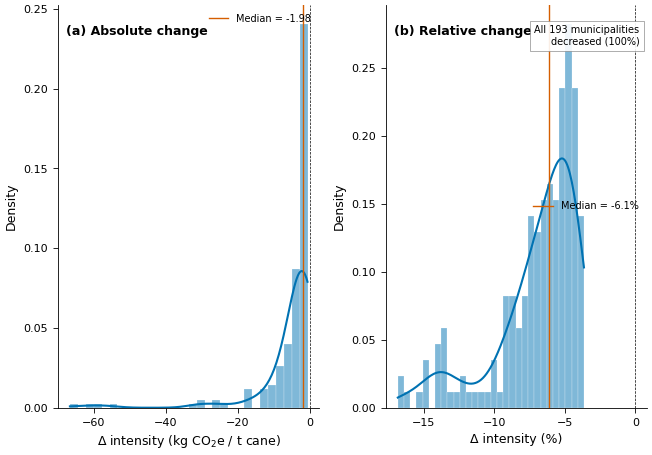

In [14]:
fig, axes = plt.subplots(1, 2, figsize=DOUBLE_COL)

# Panel A: absolute delta
ax = axes[0]
delta_abs = b4m8["delta_intensity_kgco2_ton"]
ax.hist(delta_abs, bins=30, density=True, color=COLORS["treated"], alpha=0.5,
        edgecolor="white", linewidth=0.3)
# KDE
from scipy.stats import gaussian_kde
kde_x = np.linspace(delta_abs.min(), delta_abs.max(), 200)
kde = gaussian_kde(delta_abs)
ax.plot(kde_x, kde(kde_x), color=COLORS["treated"], lw=1.5)
ax.axvline(0, color="black", lw=0.5, ls="--")
ax.axvline(delta_abs.median(), color=COLORS["positive"], lw=1.0,
           label=f"Median = {delta_abs.median():.2f}")
ax.set_xlabel("Δ intensity (kg CO$_2$e / t cane)")
ax.set_ylabel("Density")
ax.text(0.03, 0.95, "(a) Absolute change", transform=ax.transAxes,
        fontweight="bold", fontsize=9, va="top")
ax.legend(loc="upper right", frameon=False, fontsize=7)

# Panel B: relative delta (%)
ax = axes[1]
delta_rel = b4m8["delta_relativo_pct"]
ax.hist(delta_rel, bins=30, density=True, color=COLORS["treated"], alpha=0.5,
        edgecolor="white", linewidth=0.3)
kde_x = np.linspace(delta_rel.min(), delta_rel.max(), 200)
kde = gaussian_kde(delta_rel)
ax.plot(kde_x, kde(kde_x), color=COLORS["treated"], lw=1.5)
ax.axvline(0, color="black", lw=0.5, ls="--")
ax.axvline(delta_rel.median(), color=COLORS["positive"], lw=1.0,
           label=f"Median = {delta_rel.median():.1f}%")
ax.set_xlabel("Δ intensity (%)")
ax.set_ylabel("Density")
ax.text(0.03, 0.95, "(b) Relative change", transform=ax.transAxes,
        fontweight="bold", fontsize=9, va="top")
ax.text(0.97, 0.95, f"All {len(delta_rel)} municipalities\ndecreased (100%)",
        transform=ax.transAxes, ha="right", va="top", fontsize=7,
        bbox=dict(facecolor="white", edgecolor="grey", alpha=0.9, pad=3))
ax.legend(loc="center right", frameon=False, fontsize=7)

plt.tight_layout()
save_fig(fig, "F12_intensity_distribution")
plt.show()

## Final summary

12 figures generated and saved as both PDF (vector, primary submission) and PNG (300 dpi, preview).

| # | Figure | Purpose |
|---|---|---|
| F1 | PSM overlap (before/after) | Identification credibility |
| F2 | Cohort distribution | Universe transparency |
| F3 | Covariate balance (Love plot) | PSM diagnostic |
| F4 | Event-study main (5 panels) | Causal trajectory |
| F5 | Forest plot decomposition | ATTs B4.M.4 with 4 specs |
| F6 | Forest plot substitution | PAM + MapBiomas substitution |
| F7 | Dose-response tercile | Heterogeneity inverted-U |
| F8 | Event-study by tercile | T3 NULO_LIMPO causal |
| F9 | CO2eq balance | Channel contribution |
| F10 | Intensity pre vs post scatter | 100% drop visualization |
| F11 | Kaya by decile | Scale vs intensity by size |
| F12 | Distribution delta intensity | Robustness of −6% |

All figures use Wong (2011) colorblind-safe palette, Helvetica/Arial, no titles, Elsevier-compatible sizes (single 85mm or double 170mm column).